In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from skbio.stats.composition import clr, multi_replace
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr


In [ ]:

microbiome_data = pd.read_csv('data/microbiome.csv', index_col=0)
metabolome_data = pd.read_csv('data/metabolome.csv', index_col=0)
metadata = pd.read_csv('data/metadata.csv', index_col=0)

microbiome_data.index.name = 'SampleID'
metabolome_data.index.name = 'SampleID'
metadata.index.name = 'SampleID'

# Microbiome data is raw relative abundances (row sums = 1).
# NaN rows represent missing-modality samples — apply CLR only to real rows.
# multi_replace handles structural zeros before log, clr does the transform.
non_nan_mask = ~microbiome_data.isnull().all(axis=1)
clr_values = clr(multi_replace(microbiome_data.loc[non_nan_mask].values))
microbiome_data.loc[non_nan_mask] = clr_values

# Find samples that have BOTH modalities for training the baseline.
# After CLR, valid rows sum to ~0, so detect missing rows by NaN, not by sum.
is_missing_microbiome = microbiome_data.isnull().all(axis=1)
is_zero_row_metabolome = metabolome_data.sum(axis=1) == 0

common_samples = microbiome_data[~is_missing_microbiome].index.intersection(metabolome_data[~is_zero_row_metabolome].index)
print(f"Number of samples with both modalities: {len(common_samples)}")
X_microbiom_full = microbiome_data.loc[common_samples]
X_metabolom_full = metabolome_data.loc[common_samples]

metadata_common = metadata.loc[common_samples]
metadata_common_no_Denemark = metadata_common[metadata_common['CENTER_C'] != 'Danemark']
X_microbiom_full = X_microbiom_full.loc[metadata_common_no_Denemark.index]
X_metabolom_full = X_metabolom_full.loc[metadata_common_no_Denemark.index]

metadata_common_no_Denemark = pd.get_dummies(metadata_common_no_Denemark, columns=['CENTER_C', 'PATGROUPFINAL_C'], drop_first=True).astype(float)
print(f"Number of samples after removing Denmark: {len(metadata_common_no_Denemark)}")


Number of samples with both modalities: 1042
Number of samples after removing Denmark: 757


In [4]:
# Split into training and validation sets to test performance
X_micro_train, X_micro_val, X_metabolome_train, X_metabolome_val = train_test_split(
    X_microbiom_full, X_metabolom_full, test_size=0.2, random_state=42
)

#Merge training data with metadata
X_micro_train_with_metadata = X_micro_train.merge(metadata_common_no_Denemark, left_index=True, right_index=True)
X_metabolome_train_with_metadata = X_metabolome_train.merge(metadata_common_no_Denemark, left_index=True, right_index=True)
X_micro_val_with_metadata = X_micro_val.merge(metadata_common_no_Denemark, left_index=True, right_index=True)
X_metabolome_val_with_metadata = X_metabolome_val.merge(metadata_common_no_Denemark, left_index=True, right_index=True)

# --- Direction A: Metabolome + metadata -> Microbiome ---
print("Training: Metabolome to Predict Microbiome...")
rf_to_micro = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, max_features=0.33, n_jobs=-1))
rf_to_micro.fit(X_metabolome_train_with_metadata, X_micro_train)
# Predict on validation set
pred_micro_val = rf_to_micro.predict(X_metabolome_val_with_metadata)

# --- Direction B: Microbiome + metadata -> Metabolome ---
print("Training: Microbiome to Predict Metabolome...")
rf_to_metabolome = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, max_features=0.33, n_jobs=-1))
rf_to_metabolome.fit(X_micro_train_with_metadata, X_metabolome_train)
# Predict on validation set
pred_metabolome_val = rf_to_metabolome.predict(X_micro_val_with_metadata)

Training: Metabolome to Predict Microbiome...
Training: Microbiome to Predict Metabolome...


In [ ]:
def compute_project_distance_matrix(micro_df, metabolome_df, scaler_micro=None, scaler_meta=None, pca=None):
    """Replicates the project's ground truth distance matrix generation.
    
    Pass pre-fitted scaler_micro, scaler_meta, pca to project into an existing space
    (use .transform only). Omit them to fit a new space and get them back as returns.
    """
    # 1. Align rows
    common_idx = micro_df.index.intersection(metabolome_df.index)
    micro_aligned = micro_df.loc[common_idx]
    metabolome_aligned = metabolome_df.loc[common_idx]

    # 2. Scale each modality so metabolome magnitude doesn't dominate PCA.
    #    Fit on ground truth; reuse the same scaler for predicted data so the
    #    coordinate system stays identical across both calls.
    if scaler_micro is None:
        scaler_micro = StandardScaler()
        micro_scaled = scaler_micro.fit_transform(micro_aligned)
    else:
        micro_scaled = scaler_micro.transform(micro_aligned)

    if scaler_meta is None:
        scaler_meta = StandardScaler()
        metabolome_scaled = scaler_meta.fit_transform(metabolome_aligned)
    else:
        metabolome_scaled = scaler_meta.transform(metabolome_aligned)

    # 3. Combine microbiome and metabolome features
    combined_features = np.hstack((micro_scaled, metabolome_scaled))

    # 4. PCA to 2 components — same reasoning: fit once on ground truth, reuse for predicted
    if pca is None:
        pca = PCA(n_components=2)
        pca_coords = pca.fit_transform(combined_features)
    else:
        pca_coords = pca.transform(combined_features)

    print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

    # 5. Euclidean distance matrix
    dist_matrix = squareform(pdist(pca_coords, metric='euclidean'))
    print(f"Distance matrix shape: {dist_matrix.shape}")
    print(f"Distance matrix sample values:\n{dist_matrix[:6, :6]}")
    return dist_matrix, scaler_micro, scaler_meta, pca

def mantel_test(mat1, mat2):
    """Simplified Mantel test using Spearman correlation of the upper triangles"""
    tri_rows, tri_cols = np.triu_indices(mat1.shape[0], k=1)
    vec1 = mat1[tri_rows, tri_cols]
    vec2 = mat2[tri_rows, tri_cols]
    print(f"vec1 sample values: {vec1[:5]}")
    print(f"vec2 sample values: {vec2[:5]}")
    print("len(vec1):", len(vec1))
    correlation, p_value = spearmanr(vec1, vec2)
    print(f"p-value: {p_value:.8e}")
    return correlation

# --- EVALUATION ---

df_pred_micro_val = pd.DataFrame(pred_micro_val, index=X_micro_val.index, columns=X_micro_val.columns)
df_pred_metabolome_val = pd.DataFrame(pred_metabolome_val, index=X_metabolome_val.index, columns=X_metabolome_val.columns)

# 1. Ground truth distance matrix — fit scalers and PCA here
print("Computing ground truth distance matrix using actual validation data...")
gt_distance_matrix, scaler_micro, scaler_meta, pca_fitted = compute_project_distance_matrix(
    X_micro_val, X_metabolome_val
)

# 2. Predicted distance matrix — reuse the same scalers and PCA so both matrices
#    live in the same coordinate space and distances are directly comparable
print("Computing predicted distance matrix using predicted microbiome...")
pred_distance_matrix_micro, _, _, _ = compute_project_distance_matrix(
    df_pred_micro_val, df_pred_metabolome_val,
    scaler_micro=scaler_micro, scaler_meta=scaler_meta, pca=pca_fitted
)

# 3. Mantel test
baseline_score = mantel_test(gt_distance_matrix, pred_distance_matrix_micro)
print(f"Baseline Mantel Correlation (Random Forest Imputation): {baseline_score:.4f}")


Computing ground truth distance matrix using actual validation data...
PCA explained variance ratio: [0.13943264 0.09717964]
Distance matrix shape: (152, 152)
Distance matrix sample values:
[[ 0.         10.66228013  9.58702784 10.59965475 16.78096027  6.5869143 ]
 [10.66228013  0.         12.27195471 19.60445817 10.20149858  6.84586433]
 [ 9.58702784 12.27195471  0.         10.14022279 11.08949289  5.76388573]
 [10.59965475 19.60445817 10.14022279  0.         21.19259749 13.06393907]
 [16.78096027 10.20149858 11.08949289 21.19259749  0.         10.20685231]
 [ 6.5869143   6.84586433  5.76388573 13.06393907 10.20685231  0.        ]]
Computing predicted distance matrix using predicted microbiome...
PCA explained variance ratio: [0.13943264 0.09717964]
Distance matrix shape: (152, 152)
Distance matrix sample values:
[[0.         1.41797954 3.29560019 2.88007501 3.1868874  1.43221694]
 [1.41797954 0.         4.21222508 2.91368687 4.60359505 2.15315534]
 [3.29560019 4.21222508 0.         2

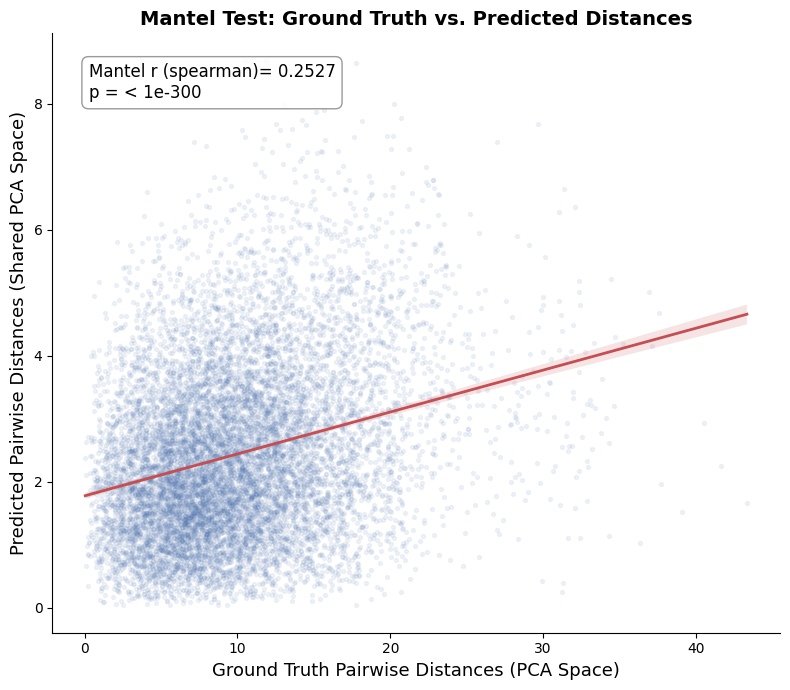

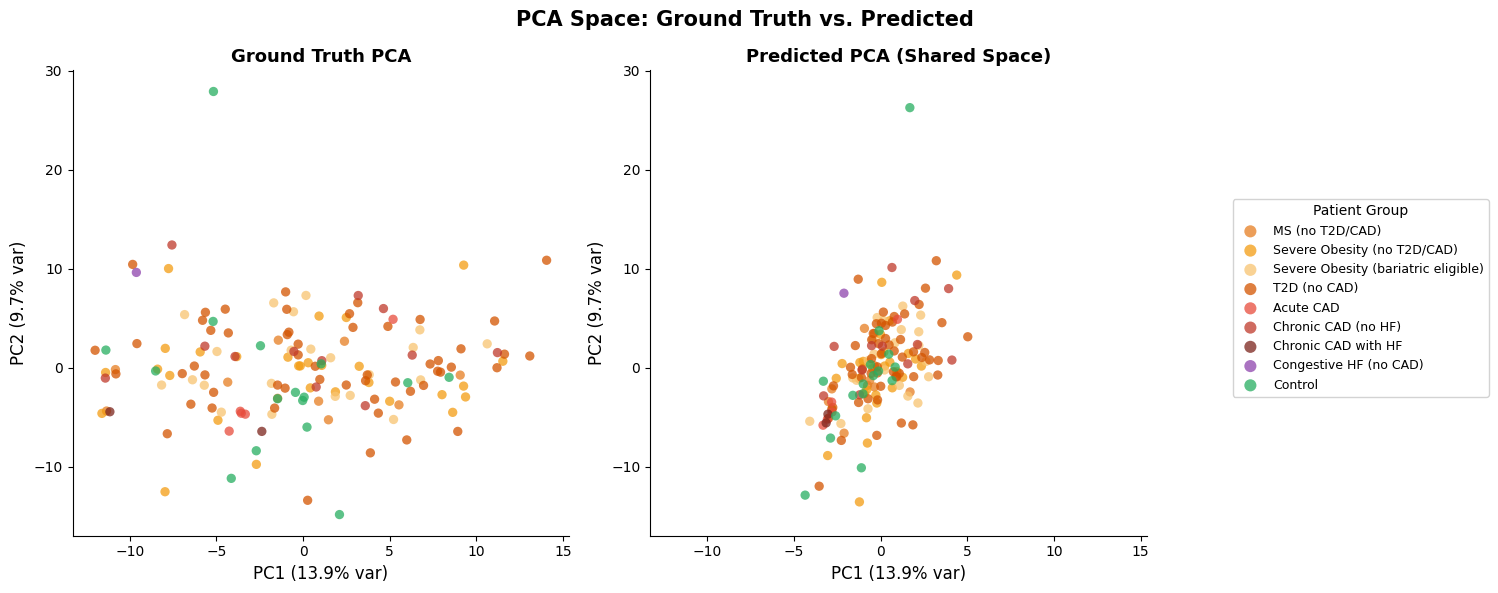

(<Figure size 1500x600 with 2 Axes>,
 array([<Axes: title={'center': 'Ground Truth PCA'}, xlabel='PC1 (13.9% var)', ylabel='PC2 (9.7% var)'>,
        <Axes: title={'center': 'Predicted PCA (Shared Space)'}, xlabel='PC1 (13.9% var)', ylabel='PC2 (9.7% var)'>],
       dtype=object))

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_mantel_distances_regression(true_dist_matrix, pred_dist_matrix, mantel_r, p_value):
    tri_idx = np.triu_indices(true_dist_matrix.shape[0], k=1)
    true_dists = true_dist_matrix[tri_idx]
    pred_dists = pred_dist_matrix[tri_idx]

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.regplot(
        x=true_dists, y=pred_dists, ax=ax,
        scatter_kws={"alpha": 0.08, "s": 8, "color": "#4C72B0", "rasterized": True},
        line_kws={"color": "#C44E52", "linewidth": 2},
    )
    ax.set_xlabel("Ground Truth Pairwise Distances (PCA Space)", fontsize=13)
    ax.set_ylabel("Predicted Pairwise Distances (Shared PCA Space)", fontsize=13)
    ax.set_title("Mantel Test: Ground Truth vs. Predicted Distances", fontsize=14, fontweight="bold")

    p_str = "< 1e-300" if p_value == 0.0 else (f"{p_value:.2e}" if p_value < 0.001 else f"{p_value:.4f}")
    ax.text(0.05, 0.95, f"Mantel r (spearman)= {mantel_r:.4f}\np = {p_str}",
            transform=ax.transAxes, fontsize=12, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#888888", alpha=0.85))
    sns.despine()
    plt.tight_layout()
    plt.show()
    return fig, ax


GROUP_NAMES = {
    "1":  "MS (no T2D/CAD)",
    "2a": "Severe Obesity (no T2D/CAD)",
    "2b": "Severe Obesity (bariatric eligible)",
    "3":  "T2D (no CAD)",
    "4":  "Acute CAD",
    "5":  "Chronic CAD (no HF)",
    "6":  "Chronic CAD with HF",
    "7":  "Congestive HF (no CAD)",
    "8":  "Control",
}

# Colors grouped by disease category:
#   Green  → healthy control
#   Orange → metabolic/obesity cluster (MS, Obesity, T2D)
#   Red    → cardiovascular/CAD cluster
#   Purple → heart failure without CAD
GROUP_COLORS = {
    "8":  "#27ae60",  # Control — green
    "1":  "#e67e22",  # MS — orange
    "2a": "#f39c12",  # Severe Obesity — amber
    "2b": "#f8c471",  # Severe Obesity bariatric — light amber
    "3":  "#d35400",  # T2D — burnt orange (bridges metabolic → CV)
    "4":  "#e74c3c",  # Acute CAD — vivid red
    "5":  "#c0392b",  # Chronic CAD — pomegranate
    "6":  "#7b241c",  # Chronic CAD + HF — dark crimson
    "7":  "#8e44ad",  # Congestive HF no CAD — purple
}

def plot_side_by_side_pca(true_pca_coords, pred_pca_coords, metadata_labels=None, explained_variance=None):
    pc1_label = f"PC1 ({explained_variance[0]*100:.1f}% var)" if explained_variance is not None else "PC1"
    pc2_label = f"PC2 ({explained_variance[1]*100:.1f}% var)" if explained_variance is not None else "PC2"

    all_coords = np.vstack([true_pca_coords, pred_pca_coords])
    x_pad = (all_coords[:, 0].max() - all_coords[:, 0].min()) * 0.05
    y_pad = (all_coords[:, 1].max() - all_coords[:, 1].min()) * 0.05
    xlim = (all_coords[:, 0].min() - x_pad, all_coords[:, 0].max() + x_pad)
    ylim = (all_coords[:, 1].min() - y_pad, all_coords[:, 1].max() + y_pad)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    if metadata_labels is not None:
        categories = sorted(np.unique(metadata_labels), key=lambda x: str(x))

    legend_handles = []

    for ax, coords, title in zip(axes, [true_pca_coords, pred_pca_coords],
                                  ["Ground Truth PCA", "Predicted PCA (Shared Space)"]):
        if metadata_labels is not None:
            for cat in categories:
                mask = np.array(metadata_labels) == cat
                display_name = GROUP_NAMES.get(str(cat), str(cat))
                color = GROUP_COLORS.get(str(cat), "#999999")
                sc = ax.scatter(coords[mask, 0], coords[mask, 1],
                                label=display_name, color=color,
                                alpha=0.75, s=45, edgecolors="none")
                if ax is axes[0]:
                    legend_handles.append(sc)
        else:
            ax.scatter(coords[:, 0], coords[:, 1], alpha=0.65, s=40,
                       color="#4C72B0", edgecolors="none")

        ax.set_xlabel(pc1_label, fontsize=12)
        ax.set_ylabel(pc2_label, fontsize=12)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        sns.despine(ax=ax)

    if metadata_labels is not None:
        fig.legend(
            handles=legend_handles,
            labels=[GROUP_NAMES.get(str(cat), str(cat)) for cat in categories],
            title="Patient Group", title_fontsize=10, fontsize=9,
            loc="center right", bbox_to_anchor=(1.0, 0.5),
            markerscale=1.3, framealpha=0.85,
        )
        plt.subplots_adjust(right=0.78)

    plt.suptitle("PCA Space: Ground Truth vs. Predicted", fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 0.78, 1] if metadata_labels is not None else None)
    plt.show()
    return fig, axes


# --- Extract PCA coordinates using already-fitted objects from the evaluation cell ---
gt_combined   = np.hstack([scaler_micro.transform(X_micro_val), scaler_meta.transform(X_metabolome_val)])
pred_combined = np.hstack([scaler_micro.transform(df_pred_micro_val), scaler_meta.transform(X_metabolome_val)])
true_pca_coords = pca_fitted.transform(gt_combined)
pred_pca_coords = pca_fitted.transform(pred_combined)

# Plot 1: regression scatter
plot_mantel_distances_regression(gt_distance_matrix, pred_distance_matrix_micro,
                                  mantel_r=baseline_score, p_value=0.0)

# Plot 2: side-by-side PCA coloured by disease group
disease_labels = metadata.loc[X_micro_val.index, "PATGROUPFINAL_C"].values if "PATGROUPFINAL_C" in metadata.columns else None
plot_side_by_side_pca(true_pca_coords, pred_pca_coords,
                       metadata_labels=disease_labels,
                       explained_variance=pca_fitted.explained_variance_ratio_)
